In [1]:
import torch
import pandas as pd
import numpy as np
import math
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

In [2]:
# SET SEED FOR REPRODUCIBILITY
SEED = 42

In [3]:
# READ THE DATASET
df = pd.read_csv('diabetes.csv')

df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [4]:
# CHECK FOR NULL VALUES
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [5]:
# SUMMARY OF THE DATASET
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [6]:
# CONVERT ALL 0's IN THE TARGET COLUMN TO -1
# SINCE THE PERCEPTRON MODEL EXPECTS THE TARGET OUTPUTS TO BE +1 OR -1
df.loc[df['Outcome'] == 0, 'Outcome'] = -1

df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,-1
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,-1
4,0,137,40,35,168,43.1,2.288,33,1


In [7]:
# SCALER TO SCALE THE INPUT VALUES IN THE RANGE [-1,1]
scaler = MinMaxScaler(feature_range=(-1, 1))

In [8]:
# DROP THE 'Outcome' COLUMN AND THEN SCALE THE INPUT FEATURES
x = scaler.fit_transform(df.drop('Outcome', axis=1))
# GET THE OUTPUT VALUES
y = df['Outcome'].values

# SPLIT THE DATASET INTO TRAINING AND TEST SET
x_train_full, x_test, y_train_full, y_test = train_test_split(x, y, test_size=0.1, stratify=y, random_state=SEED)
# SPLIT THE TRAINING SET FURTHER INTO TRAINING AND VALIDATION SET
x_train, x_val, y_train, y_val = train_test_split(x_train_full, y_train_full, test_size=0.1, stratify=y_train_full, random_state=SEED)

# CONVERT DATA TO PYTORCH TENSORS
x_train = torch.tensor(x_train, dtype=torch.float64)
x_val = torch.tensor(x_val, dtype=torch.float64)
x_test = torch.tensor(x_test, dtype=torch.float64)
y_train = torch.tensor(y_train, dtype=torch.float64)
y_val = torch.tensor(y_val, dtype=torch.float64)
y_test = torch.tensor(y_test, dtype=torch.float64)

In [9]:
torch.unique(y_train, return_counts=True)

(tensor([-1.,  1.], dtype=torch.float64), tensor([404, 217]))

1.   Split the dataset into three datasets
2.   Evaluate on validation datasets and then display the final result using test set
3.   Display the confusion matrix
4.   Give reasoning behind improvements
5.   The order in which data is inputted to the model matters

**BASELINE MODEL**

In [10]:
# LEARNING-RATE / STEP-SIZE
lr = 0.1

# NO. OF ITERATIONS
n_iter = 500

In [11]:
# WEIGHT VECTOR
# INITIALIZED TO ZERO
w1 = torch.zeros(x.shape[1], dtype=torch.float64)

In [12]:
# INDICATOR FUNCTION
# IT RETURNS 1 WHEN THE PERCEPTRON MAKES A MISCLASSIFICATION
# OR RETURNS 0 OTHERWISE
def indicator_func(xi,yi,w):
    if yi*(torch.dot(w,xi)) <= 0:
        return 1
    else:
        return 0

In [13]:
# PERCEPTRON LOSS FUNCTION
# IT CALCULATES THE AVERAGE PERCEPTRON LOSS FOR ALL THE DATA POINTS
def loss_func(x,y,w):
    loss = 0

    for i in range(x.shape[0]):
        xi = x[i]
        yi = y[i]
        loss += max(0, -yi*(torch.dot(w,xi)))

    return loss/x.shape[0]

In [14]:
# FUNCTION TO RETURN MODEL PREDICTIONS
def predict(x,w):
    preds = []

    for i in range(x.shape[0]):
        xi = x[i]
        pred = torch.sign(torch.dot(w,xi))
        preds.append(pred)

    return torch.tensor(preds)

In [15]:
# FUNCTION TO PLOT THE LOSS CURVE
def plot_losses(losses, xlabel='', ylabel=''):
    plt.figure(figsize=(10, 6))

    plt.grid(True, which='both', linestyle='--', linewidth=0.7, alpha=0.7)

    plt.plot(list(range(1,500,10)), losses, color='b', linestyle='-', linewidth=2, marker='D', markersize=5)

    plt.xticks(list(range(1,550,50)))
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.tight_layout()
    plt.show()

In [16]:
val_losses = []

In [17]:
for j in range(n_iter):
    # VECTOR USED TO UPDATE THE WEIGHT VECTOR
    weight_update = torch.zeros_like(w1)

    for i in range(x_train.shape[0]):
        # INPUT VECTOR
        xi = x_train[i]
        # TARGET LABEL
        yi = y_train[i]
        # VALUE OF INDICATOR FUNCTION
        ind = indicator_func(xi,yi,w1)

        # ADD THE PERCEPTRON UPDATES FOR EACH ITERATION
        weight_update = weight_update + (yi*xi*ind)

    # UPDATE THE WEIGHT VECTOR
    w1 = w1 + lr*weight_update

    if j%10 == 0:
        # CALCULATE THE PERCEPTRON LOSS ON THE VALIDATION DATASET
        val_losses.append(loss_func(x_val,y_val,w1))

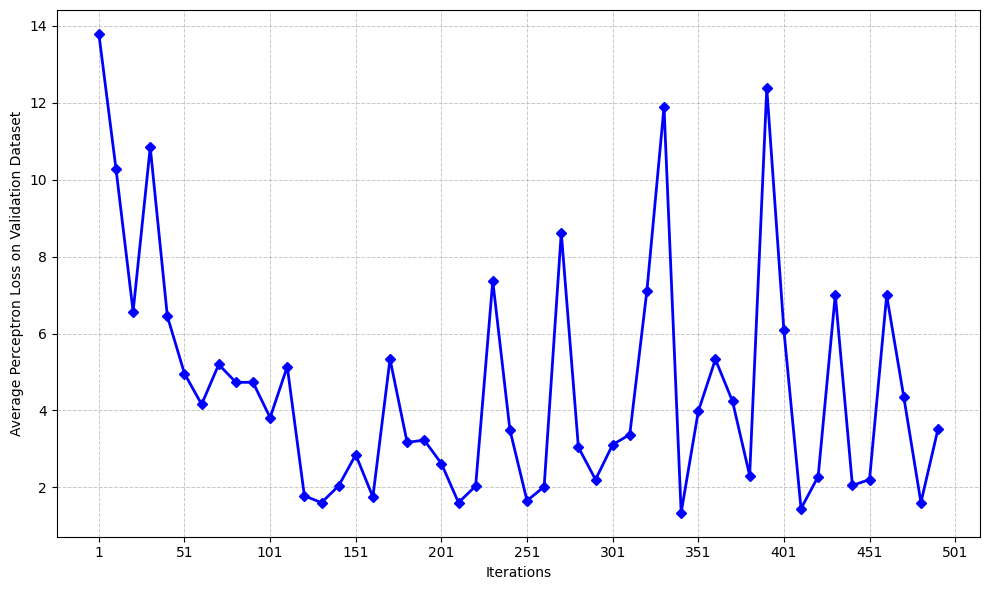

In [18]:
# PLOT THE VALIDATION SET LOSS CURVE
plot_losses(val_losses, 'Iterations', 'Average Perceptron Loss on Validation Dataset')

In [19]:
# GET THE MODEL PREDICTIONS ON THE VALIDATION SET
preds = predict(x_val,w1)

print(f'VALIDATION ACCURACY: {round(accuracy_score(y_val, preds)*100,2)}%')
print(f'VALIDATION PRECISION: {round(precision_score(y_val, preds)*100,2)}%')
print(f'VALIDATION RECALL: {round(recall_score(y_val, preds)*100,2)}%')
print(f'VALIDATION F1: {round(f1_score(y_val, preds)*100,2)}%')

VALIDATION ACCURACY: 71.43%
VALIDATION PRECISION: 100.0%
VALIDATION RECALL: 16.67%
VALIDATION F1: 28.57%


In [20]:
# OUTPUT THE WEIGHT VECTOR
w1

tensor([ 21.1294,  29.5859, -10.6246,  10.1596,  13.4359,  28.8504,  24.9330,
         15.4867], dtype=torch.float64)

POTENTIAL IMPROVEMENTS:-


3.   Change learning rate. Use learning rate scheduler
4.   Consider advanced optimizers such as Adam, RMSprop, AdaGrad
5.   Add L1 or L2 Regularization
6.   Consider ensemble methods


**LEARNING RATE SCHEDULING**

In [21]:
# LEARNING-RATE / STEP-SIZE
lr = 0.1

In [22]:
# WEIGHT VECTOR
# INITIALIZED TO ZERO
w2 = torch.zeros(x.shape[1], dtype=torch.float64)

In [23]:
val_losses = []

In [24]:
for j in range(n_iter):
    # VECTOR USED TO UPDATE THE WEIGHT VECTOR
    weight_update = torch.zeros_like(w2)

    for i in range(x_train.shape[0]):
        # INPUT VECTOR
        xi = x_train[i]
        # TARGET LABEL
        yi = y_train[i]
        # VALUE OF INDICATOR FUNCTION
        ind = indicator_func(xi,yi,w2)

        # ADD THE PERCEPTRON UPDATES FOR EACH ITERATION
        weight_update = weight_update + (yi*xi*ind)

    # UPDATE THE WEIGHT VECTOR
    w2 = w2 + lr*weight_update

    if j%200 == 0:
        lr = lr*0.1

    if j%10 == 0:
        # CALCULATE THE PERCEPTRON LOSS ON THE VALIDATION DATASET
        val_losses.append(loss_func(x_val,y_val,w2))

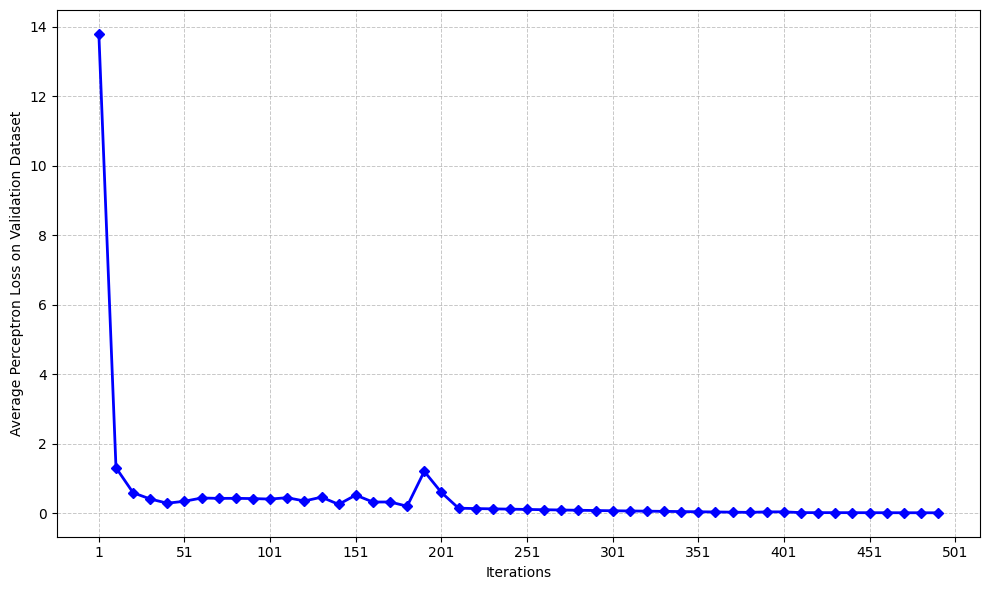

In [25]:
# PLOT THE VALIDATION SET LOSS CURVE
plot_losses(val_losses, 'Iterations', 'Average Perceptron Loss on Validation Dataset')

In [26]:
# GET THE MODEL PREDICTIONS ON THE VALIDATION SET
preds = predict(x_val,w2)

print(f'VALIDATION ACCURACY: {round(accuracy_score(y_val, preds)*100,2)}%')
print(f'VALIDATION PRECISION: {round(precision_score(y_val, preds)*100,2)}%')
print(f'VALIDATION RECALL: {round(recall_score(y_val, preds)*100,2)}%')
print(f'VALIDATION F1: {round(f1_score(y_val, preds)*100,2)}%')

VALIDATION ACCURACY: 78.57%
VALIDATION PRECISION: 66.67%
VALIDATION RECALL: 75.0%
VALIDATION F1: 70.59%


In [27]:
# OUTPUT THE WEIGHT VECTOR
w2

tensor([ 0.0621,  0.1962, -0.1059, -0.0507, -0.0427,  0.4089,  0.0962,  0.0110],
       dtype=torch.float64)

**L2 REGULARIZATION**

In [28]:
# LEARNING-RATE / STEP-SIZE
lr = 0.1

# L2 REGULARIZATION PARAMETER
l2_reg = 0.5

In [29]:
# WEIGHT VECTOR
# INITIALIZED TO ZERO
w3 = torch.zeros(x.shape[1], dtype=torch.float64)

In [30]:
val_losses = []

In [31]:
for j in range(n_iter):
    # VECTOR USED TO UPDATE THE WEIGHT VECTOR
    weight_update = torch.zeros_like(w3)

    for i in range(x_train.shape[0]):
        # INPUT VECTOR
        xi = x_train[i]
        # TARGET LABEL
        yi = y_train[i]
        # VALUE OF INDICATOR FUNCTION
        ind = indicator_func(xi,yi,w3)

        # ADD THE PERCEPTRON UPDATES FOR EACH ITERATION
        weight_update = weight_update + (yi*xi*ind)

    # UPDATE THE WEIGHT VECTOR
    w3 = w3 + lr*(weight_update - (l2_reg*w3))

    if j%200 == 0:
        lr = lr*0.1

    if j%10 == 0:
        # CALCULATE THE PERCEPTRON LOSS ON THE VALIDATION DATASET
        val_losses.append(loss_func(x_val,y_val,w3))

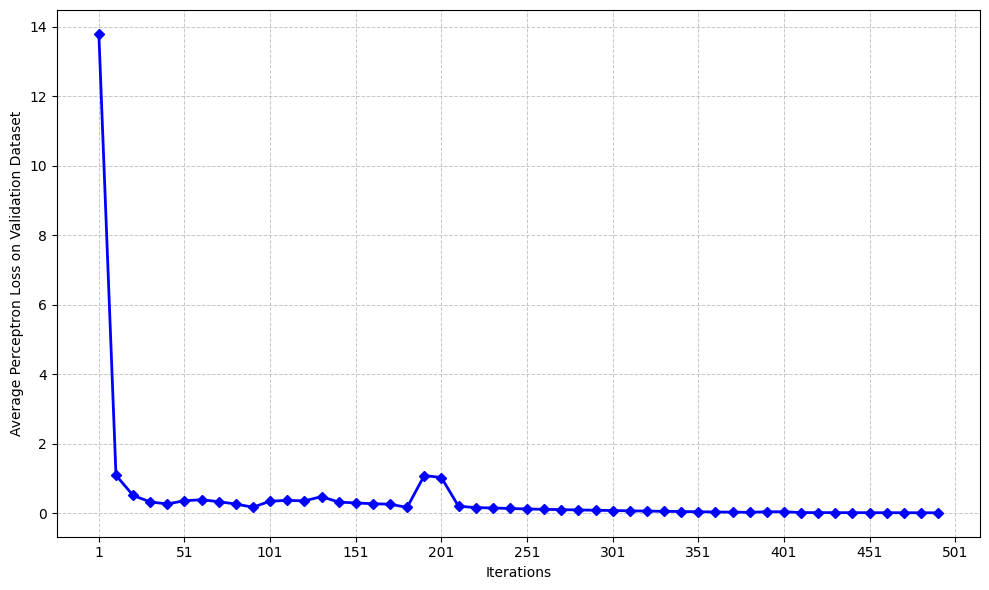

In [32]:
# PLOT THE VALIDATION SET LOSS CURVE
plot_losses(val_losses, 'Iterations', 'Average Perceptron Loss on Validation Dataset')

In [33]:
# GET THE MODEL PREDICTIONS ON THE VALIDATION SET
preds = predict(x_val,w3)

print(f'VALIDATION ACCURACY: {round(accuracy_score(y_val, preds)*100,2)}%')
print(f'VALIDATION PRECISION: {round(precision_score(y_val, preds)*100,2)}%')
print(f'VALIDATION RECALL: {round(recall_score(y_val, preds)*100,2)}%')
print(f'VALIDATION F1: {round(f1_score(y_val, preds)*100,2)}%')

VALIDATION ACCURACY: 77.14%
VALIDATION PRECISION: 65.38%
VALIDATION RECALL: 70.83%
VALIDATION F1: 68.0%


In [34]:
# OUTPUT THE WEIGHT VECTOR
w3

tensor([ 0.0635,  0.1938, -0.1020, -0.0417, -0.0453,  0.3814,  0.0922,  0.0083],
       dtype=torch.float64)